In [1]:
import os
os.environ["PYTENSOR_FLAGS"] = "device=cpu,force_linker=py,cxx="

/usr/local/python/3.12.1/lib/python3.12/site-packages/pytensor/configparser.py:316: UserWarning: PyTensor does not recognise this flag: force_linker
  warnings.warn(f"PyTensor does not recognise this flag: {key}")
/usr/local/python/3.12.1/lib/python3.12/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


Hierarchical Dataset Loaded: 1000 properties.
Reference Market Intercept: 7.5
Reference Agent Premium:   0.15


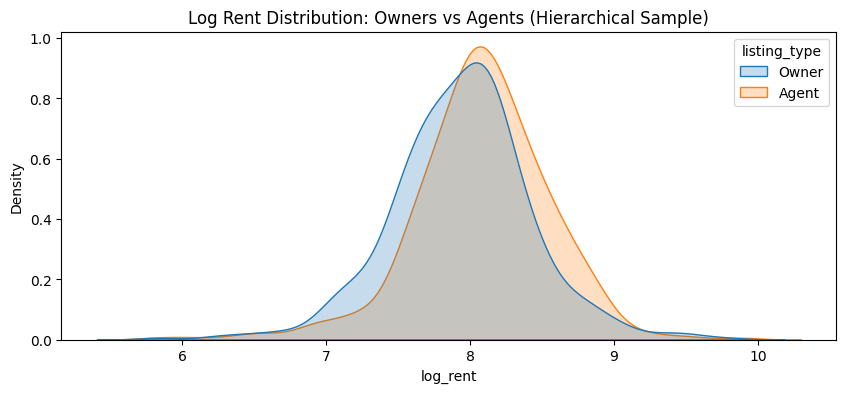

,listing_type,monthly_rent_gbp,log_rent,is_agent
0,Owner,3338.647763,8.113321,0
1,Owner,3570.013884,8.180325,0
2,Owner,4352.087688,8.378411,0
3,Owner,6632.427753,8.799726,0
4,Owner,2050.803861,7.625987,0


In [2]:
import json
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. LOAD HIERARCHICAL DATASET ---
# We load the JSON to access the 'metadata' (the true market hyper-parameters)
filename = "../../data/datasets/london_rentals_hierarchical.json"

with open(filename, 'r') as f:
    raw_data = json.load(f)

# Convert properties back to a DataFrame
df = pd.DataFrame(raw_data['properties'])
# Extract the truths for Case B (Agents) as our reference for recovery
market_truth = raw_data['metadata']['agent_market_truth']

# --- 2. FEATURE ENGINEERING & INDEXING ---
df['log_rent'] = np.log(df['monthly_rent_gbp'])

# Categorical mapping for the likelihood function
df['is_house'] = df['property_type'].map({'House': 1, 'Flat': 0})
df['has_garden'] = (df['outdoor_space'] == 'Garden').astype(int)
df['has_terrace'] = (df['outdoor_space'] == 'Terrace').astype(int)
df['has_balcony'] = (df['outdoor_space'] == 'Balcony').astype(int)

# Create an 'is_agent' indicator (0 for Owner, 1 for Agent)
# This allows the model to 'turn on' the premium for the Agent group
df['is_agent'] = (df['listing_type'] == 'Agent').astype(int)

# --- 3. SETTING HYPER-PRIOR REFERENCES ---
# We pull these directly from your 'metadata' to see how well we recover them later
INTERCEPT_MU = market_truth['means']['intercept']
ROOM_MU      = market_truth['means']['beta_room']
DIST_MU      = market_truth['means']['beta_dist']
UNDER_MU     = market_truth['means']['beta_under']
HOUSE_MU     = market_truth['means']['beta_house']
GARDEN_MU    = market_truth['means']['beta_garden']
TERRACE_MU   = market_truth['means']['beta_terrace']
BALCONY_MU   = market_truth['means']['beta_balcony']
PREMIUM_MU   = market_truth['means']['premium'] 

# Reference Volatility (Global Market Volatility)
MARKET_VOL = 0.03 

print(f"Hierarchical Dataset Loaded: {len(df)} properties.")
print(f"Reference Market Intercept: {INTERCEPT_MU}")
print(f"Reference Agent Premium:   {PREMIUM_MU}")

# Visual check of the log_rent distribution across groups
plt.figure(figsize=(10, 4))
sns.kdeplot(data=df, x='log_rent', hue='listing_type', fill=True, common_norm=False)
plt.title("Log Rent Distribution: Owners vs Agents (Hierarchical Sample)")
plt.show()

df[['listing_type', 'monthly_rent_gbp', 'log_rent', 'is_agent']].head()

In [3]:
# 1. SELECT THE TEST PROPERTY
idx = 505  # Let's pick a property from the 'Agent' half (500-999)
test_prop = df.iloc[idx]
y_obs = test_prop['log_rent']

print(f"Testing Property ID: {test_prop.get('id', idx)}")
print(f"Observed Log Price: {y_obs:.4f}")
print(f"True Listing Type: {test_prop['listing_type']}")
print("-" * 30)

def run_model_selection_hierarchical(y, prop_data, market_truth, mc_draws=1000, is_agent_hyp=False):
    """
    Computes Log-Evidence using specific Hierarchical Market Sigmas.
    """
    means = market_truth['means']
    sigmas = market_truth['sigmas']
    
    with pm.Model() as model:
        # --- PRIORS: Using the Hierarchical Market Sigmas ---
        intercept = pm.Normal("intercept", mu=means['intercept'], sigma=sigmas['intercept'])
        beta_dist = pm.Normal("beta_dist", mu=means['beta_dist'], sigma=sigmas['beta_dist'])
        
        # Room impact was generated as Laplace
        beta_room = pm.Laplace("beta_room", mu=means['beta_room'], b=sigmas['beta_room'])
        
        mu = (
            intercept +
            (prop_data['n_rooms'] * beta_room) +
            (prop_data['dist_centre_km'] * beta_dist)
        )

        # --- STRUCTURAL FEATURES ---
        if prop_data['near_underground'] == 1:
            mu += pm.Normal("beta_under", mu=means['beta_under'], sigma=sigmas['beta_under'])

        if prop_data['property_type'] == 'House':
            mu += pm.Normal("beta_house", mu=means['beta_house'], sigma=sigmas['beta_house'])
            
        outdoor = prop_data['outdoor_space']
        if outdoor == 'Garden':
            mu += pm.Normal("beta_garden", mu=means['beta_garden'], sigma=sigmas['beta_garden'])
        elif outdoor == 'Terrace':
            mu += pm.Normal("beta_terrace", mu=means['beta_terrace'], sigma=sigmas['beta_terrace'])
        elif outdoor == 'Balcony':
            mu += pm.Normal("beta_balcony", mu=means['beta_balcony'], sigma=sigmas['beta_balcony'])
        
        # --- AGENT PREMIUM (Case B Logic) ---
        if is_agent_hyp:
            # We recover the alpha (shape) and beta (rate) from our truth sigmas
            # Variance of Gamma = alpha / beta^2
            mu_p = means['premium']
            sig_p = sigmas['premium']
            alpha_p = (mu_p / sig_p)**2
            beta_p = mu_p / (sig_p**2)
            
            premium = pm.Gamma("premium", alpha=alpha_p, beta=beta_p)
            mu += premium
        
        # --- LIKELIHOOD ---
        # nu=5 matches your standard_t(df=5) generation
        pm.StudentT("obs", nu=5, mu=mu, sigma=0.05, observed=y)
        
        # --- SMC SAMPLING ---
        trace = pm.sample_smc(
            draws=mc_draws, 
            chains=4, 
            progressbar=True,
            return_inferencedata=True,
        )
        
        return trace

# 2. EXECUTION
mc_draws = 1000
print("Computing Evidence: OWNER Hypothesis...")
owner_trace = run_model_selection_hierarchical(y_obs, test_prop, market_truth, mc_draws, is_agent_hyp=False)
log_z_owner = owner_trace.sample_stats.log_marginal_likelihood.mean().item()

print("Computing Evidence: AGENT Hypothesis...")
agent_trace = run_model_selection_hierarchical(y_obs, test_prop, market_truth, mc_draws, is_agent_hyp=True)
log_z_agent = agent_trace.sample_stats.log_marginal_likelihood.mean().item()

# 3. ANALYSIS
log_BF = log_z_agent - log_z_owner
BF = np.exp(log_BF)

print("\n--- RESULTS ---")
print(f"Log Z (Owner): {log_z_owner:.4f}")
print(f"Log Z (Agent): {log_z_agent:.4f}")
print(f"Bayes Factor (K): {BF:.4f}")

if BF > 10:
    print("Conclusion: Strong Evidence for AGENT model.")
elif BF < 0.1:
    print("Conclusion: Strong Evidence for OWNER model.")
else:
    print("Conclusion: Ambiguous Evidence (Inconclusive).")

Initializing SMC sampler...


Testing Property ID: 505
Observed Log Price: 8.1184
True Listing Type: Agent
------------------------------
Computing Evidence: OWNER Hypothesis...


Sampling 4 chains sequentially


Output()

/usr/local/python/3.12.1/lib/python3.12/site-packages/arviz/data/base.py:272: UserWarning: More chains (4) than draws (2). Passed array should have shape (chains, draws, *shape)
  warnings.warn(
Initializing SMC sampler...


Computing Evidence: AGENT Hypothesis...


Sampling 4 chains sequentially


Output()


--- RESULTS ---
Log Z (Owner): 0.6395
Log Z (Agent): 0.3495
Bayes Factor (K): 0.7483
Conclusion: Ambiguous Evidence (Inconclusive).


/usr/local/python/3.12.1/lib/python3.12/site-packages/arviz/data/base.py:272: UserWarning: More chains (4) than draws (2). Passed array should have shape (chains, draws, *shape)
  warnings.warn(


In [ ]:
def run_hierarchical_model_selection(df_subset, market_truth, mc_draws=2000, is_agent_hyp=False):
    """
    Computes the Marginal Likelihood (Log Z) for a group of properties 
    using a Hierarchical Bayesian framework.
    
    METHODOLOGY:
    1. Hyper-priors: We define distributions for the UNKNOWN market means and sigmas.
    2. Latent Variables: Every property 'i' gets its own set of betas (non-centered 
       parameterization is used implicitly by PyMC for efficiency).
    3. Integration: SMC (Sequential Monte Carlo) integrates over the joint space of 
       (Market Hyper-parameters X Individual Property Parameters).
       
    MATH:
    Log_Rent_i ~ StudentT(nu=5, mu_i, sigma=0.05)
    mu_i = Intercept_i + (Rooms_i * Beta_Room_i) + ... + [Premium_i if Agent]
    Intercept_i ~ Normal(mu_market_intercept, sigma_market_intercept)
    Beta_Room_i ~ Laplace(mu_market_room, b_market_room)
    """
    
    # Pre-calculate feature presence to avoid boolean checks inside the loop
    n_props = len(df_subset)
    rooms = df_subset['n_rooms'].values
    dist = df_subset['dist_centre_km'].values
    is_under = df_subset['near_underground'].values
    is_house = (df_subset['property_type'] == 'House').astype(int)
    is_garden = (df_subset['outdoor_space'] == 'Garden').astype(int)
    is_terrace = (df_subset['outdoor_space'] == 'Terrace').astype(int)
    is_balcony = (df_subset['outdoor_space'] == 'Balcony').astype(int)
    y_obs = df_subset['log_rent'].values

    # Pre-calculate the market truth means
    mt_mu_inter = market_truth["means"]["intercept"]
    mt_mu_beta_room = market_truth["means"]["beta_room"]
    mt_mu_beta_dist = market_truth["means"]["beta_dist"]
    mt_mu_beta_under = market_truth["means"]["beta_under"]
    mt_mu_beta_house = market_truth["means"]["beta_house"]
    mt_mu_beta_garden = market_truth["means"]["beta_garden"]
    mt_mu_beta_terrace = market_truth["means"]["beta_terrace"]
    mt_mu_beta_balcony = market_truth["means"]["beta_balcony"]
    mt_mu_premium = market_truth["means"]["premium"]
    # Pre-calculate the market truth sigmas
    mt_sig_inter = market_truth["sigmas"]["intercept"]
    mt_sig_beta_room = market_truth["sigmas"]["beta_room"]
    mt_sig_beta_dist = market_truth["sigmas"]["beta_dist"]
    mt_sig_beta_under = market_truth["sigmas"]["beta_under"]
    mt_sig_beta_house = market_truth["sigmas"]["beta_house"]
    mt_sig_beta_garden = market_truth["sigmas"]["beta_garden"]
    mt_sig_beta_terrace = market_truth["sigmas"]["beta_terrace"]
    mt_sig_beta_balcony = market_truth["sigmas"]["beta_balcony"]
    mt_sig_premium = market_truth["sigmas"]["premium"]

    with pm.Model() as model:
        # --- LEVEL 2: MARKET HYPER-PRIORS (Unknown Market Parameters) ---
        # We don't assume we know the exact means; we use priors around the expected market values.
        # For simplicity, assume that the error in the market truth mean is always equal to k * market truth sigma,
        # where k is a constant, and that the error in the market truth sigma is always equal to k/sqrt(2) * market truth sigma,
        # motivated by the standard errors (SEs) of the mean and standard deviation, respectively.
        k = 0.05

        mu_m_inter = pm.Normal("mu_m_inter", mu=mt_mu_inter, sigma=k*mt_sig_inter)
        mu_m_beta_room  = pm.Normal("mu_m_beta_room", mu=mt_mu_beta_room, sigma=k*mt_sig_beta_room)
        mu_m_beta_dist  = pm.Normal("mu_m_beta_dist", mu=mt_mu_beta_dist, sigma=k*mt_sig_beta_dist)
        
        # Market Sigmas (The 'spread' of the market)
        # Intercept Sigma
        s_err_inter = (k / np.sqrt(2)) * mt_sig_inter
        sig_m_inter = pm.TruncatedNormal("sig_m_inter", 
                                         mu=mt_sig_inter, 
                                         sigma=s_err_inter, 
                                         lower=s_err_inter/100,
                                         upper=mt_sig_inter + (mt_sig_inter - s_err_inter/100))
        # Room Sigma
        s_err_room = (k / np.sqrt(2)) * mt_sig_beta_room
        sig_m_beta_room = pm.TruncatedNormal("sig_m_beta_room", 
                                             mu=mt_sig_beta_room, 
                                             sigma=s_err_room, 
                                             lower=s_err_room/100,
                                             upper=mt_sig_beta_room + (mt_sig_beta_room - s_err_room/100))
        # Distance Sigma
        s_err_dist = (k / np.sqrt(2)) * mt_sig_beta_dist
        sig_m_beta_dist = pm.TruncatedNormal("sig_m_beta_dist", 
                                             mu=mt_sig_beta_dist, 
                                             sigma=s_err_dist, 
                                             lower=s_err_dist/100,
                                             upper=mt_sig_beta_dist + (mt_sig_beta_dist - s_err_dist/100))

        # --- LEVEL 1: INDIVIDUAL PROPERTY PARAMETERS (Latent) ---
        # Every property gets its own unique draw from the market distributions
        # This handles the 'wobble' you built into the generator
        prop_intercepts = pm.Normal("p_inter", mu=mu_m_inter, sigma=sig_m_inter, shape=n_props)
        prop_rooms      = pm.Laplace("p_room", mu=mu_m_beta_room, b=sig_m_beta_room, shape=n_props)
        prop_dist       = pm.Normal("p_dist", mu=mu_m_beta_dist, sigma=sig_m_beta_dist, shape=n_props)

        # Base Linear Predictor
        mu = prop_intercepts + (rooms * prop_rooms) + (dist * prop_dist)

        # Structural Features (Partial Pooling)
        # We assume these features have relatively stable market effects
        mu += pm.Normal("b_under", mu=mt_mu_beta_under, sigma=mt_sig_beta_under) * is_under
        mu += pm.Normal("b_house", mu=mt_mu_beta_house, sigma=mt_sig_beta_house) * is_house
        mu += pm.Normal("b_garden", mu=mt_mu_beta_garden, sigma=mt_sig_beta_garden) * is_garden
        mu += pm.Normal("b_terrace", mu=mt_mu_beta_terrace, sigma=mt_sig_beta_terrace) * is_terrace
        mu += pm.Normal("b_balcony", mu=mt_mu_beta_balcony, sigma=mt_sig_beta_balcony) * is_balcony
        
        # --- HYPOTHESIS: AGENT PREMIUM ---
        if is_agent_hyp:
            mu_m_prem = pm.Normal("mu_m_prem", mu=mt_mu_premium, sigma=k*mt_sig_premium)
            s_err_prem = (k / np.sqrt(2)) * mt_sig_premium
            sig_m_prem = pm.TruncatedNormal("sig_m_prem", 
                                            mu=mt_sig_premium, 
                                            sigma=s_err_prem, 
                                            lower=s_err_prem/100,
                                            upper=mt_sig_premium + (mt_sig_premium - s_err_prem/100))
            
            # Gamma parameters derived from hyper-priors
            alpha_p = (mu_m_prem / sig_m_prem)**2
            beta_p  = mu_m_prem / (sig_m_prem**2)
            
            p_premium = pm.Gamma("p_premium", alpha=alpha_p, beta=beta_p, shape=n_props)
            mu += p_premium

        # --- LIKELIHOOD ---
        pm.StudentT("obs", nu=5, mu=mu, sigma=0.05, observed=y_obs)

        # --- SAMPLING (SMC for Marginal Likelihood) ---
        trace = pm.sample_smc(
            draws=mc_draws, 
            chains=4, 
            progressbar=True,
            return_inferencedata=True,
        )
        return trace
    
# --- EXECUTION: 10 PROPERTY BATCH TEST ---
# We take 10 properties that are ACTUALLY Agents (to see if the model detects them)
test_batch = df[df['listing_type'] == 'Agent'].head(10)

print(f"Running Hierarchical Analysis on {len(test_batch)} properties...")

mc_draws=1000
# 1. Evidence for Owner Hypothesis (Null)
res_owner = run_hierarchical_model_selection(test_batch, market_truth, mc_draws=mc_draws, is_agent_hyp=False)
log_z_owner = res_owner.sample_stats.log_marginal_likelihood.mean().item()

# 2. Evidence for Agent Hypothesis (Alternative)
res_agent = run_hierarchical_model_selection(test_batch, market_truth, mc_draws=mc_draws, is_agent_hyp=True)
log_z_agent = res_agent.sample_stats.log_marginal_likelihood.mean().item()

# 3. Bayes Factor Computation
log_BF = log_z_agent - log_z_owner
BF = np.exp(log_BF)

print("\n--- BATCH RESULTS ---")
print(f"Log Z (Owner Model): {log_z_owner:.4f}")
print(f"Log Z (Agent Model): {log_z_agent:.4f}")
print(f"Group Bayes Factor:  {BF:.4e}")

if BF > 100:
    print("Conclusion: Decisive Evidence for the AGENT hierarchy.")
elif BF < 0.01:
    print("Conclusion: Decisive Evidence for the OWNER hierarchy.")
else:
    print("Conclusion: The evidence is mixed (Partial Pooling suggests ambiguity).")

Initializing SMC sampler...


Running Hierarchical Analysis on 10 properties...


/usr/local/python/3.12.1/lib/python3.12/site-packages/pytensor/tensor/rewriting/elemwise.py:881: UserWarning: Loop fusion failed because the resulting node would exceed the kernel argument limit.
  warn(
Sampling 4 chains sequentially


Output()

Initializing SMC sampler...
/usr/local/python/3.12.1/lib/python3.12/site-packages/pytensor/tensor/rewriting/elemwise.py:881: UserWarning: Loop fusion failed because the resulting node would exceed the kernel argument limit.
  warn(
Sampling 4 chains sequentially


Output()


--- BATCH RESULTS ---
Log Z (Owner Model): -5.6553
Log Z (Agent Model): -2.5230
Group Bayes Factor:  2.2927e+01
Conclusion: The evidence is mixed (Partial Pooling suggests ambiguity).


In [37]:
# res_owner.posterior.data_vars
# res_agent.posterior.data_vars

In [ ]:
import pickle

# Emergency save using Pickle
with open("res_owner.pkl", "wb") as f:
    pickle.dump(res_owner, f)

with open("res_agent.pkl", "wb") as f:
    pickle.dump(res_agent, f)

In [5]:
import pickle

# with open("res_owner.pkl", "rb") as f:
#     res_owner = pickle.load(f)

with open("res_agent.pkl", "rb") as f:
    res_agent = pickle.load(f)

# Now you can proceed with the Bayes Factor math

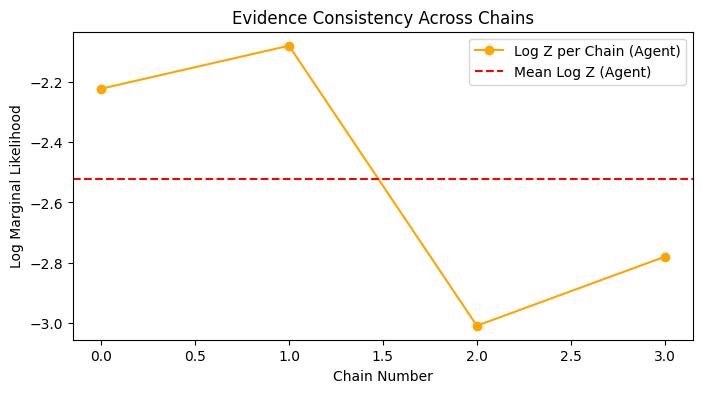

In [6]:
# Access the log_marginal_likelihood per chain
# This shows if all 4 chains reached roughly the same conclusion
# log_z_per_chain_owner = res_owner.sample_stats.log_marginal_likelihood.values[:,-1]
log_z_per_chain_agent = res_agent.sample_stats.log_marginal_likelihood.values[:,-1]

plt.figure(figsize=(8, 4))
# plt.plot(log_z_per_chain_owner, 'o-', label='Log Z per Chain (Owner)')
# plt.axhline(log_z_per_chain_owner.mean(), color='purple', linestyle='--', label='Mean Log Z (Owner)')
plt.plot(log_z_per_chain_agent, 'o-', color='orange', label='Log Z per Chain (Agent)')
plt.axhline(log_z_per_chain_agent.mean(), color='r', linestyle='--', label='Mean Log Z (Agent)')
plt.xlabel('Chain Number')
plt.ylabel('Log Marginal Likelihood')
plt.title('Evidence Consistency Across Chains')
plt.legend()
plt.show()

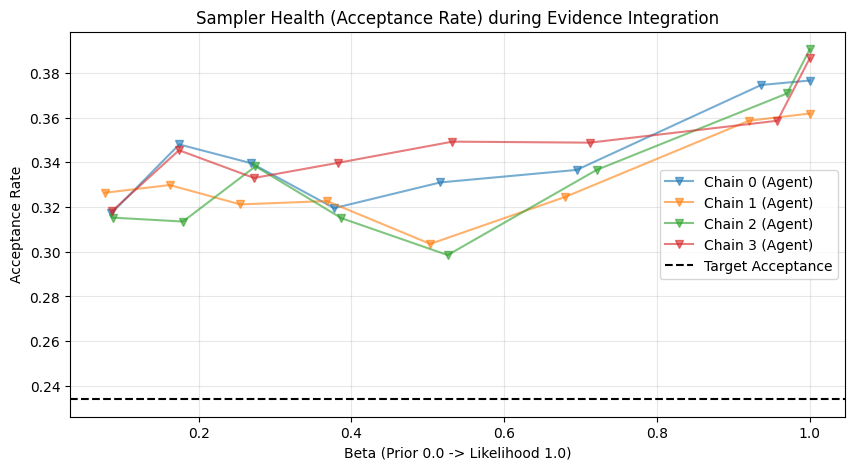

In [7]:
# Accessing the available variables from your KeyError list
# accept_rates_owner = res_owner.sample_stats["accept_rate"].values
# betas_owner = res_owner.sample_stats["beta"].values
accept_rates_agent = res_agent.sample_stats["accept_rate"].values
betas_agent = res_agent.sample_stats["beta"].values

plt.figure(figsize=(10, 5))

# Plotting the acceptance rate across stages
# Note: In SMC, 'draw' index usually corresponds to the stage index here
# for i in range(accept_rates_owner.shape[0]):
#     plt.plot(betas_owner[i], accept_rates_owner[i], 'o-', alpha=0.6, label=f'Chain {i} (Owner)')
for i in range(accept_rates_agent.shape[0]):
    plt.plot(betas_agent[i], accept_rates_agent[i], 'v-', alpha=0.6, label=f'Chain {i} (Agent)')
plt.axhline(y=0.234, color='k', linestyle='--', label='Target Acceptance')
plt.xlabel('Beta (Prior 0.0 -> Likelihood 1.0)')
plt.ylabel('Acceptance Rate')
plt.title('Sampler Health (Acceptance Rate) during Evidence Integration')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

--- MARKET HYPER-PARAMETERS (GLOBAL) ---


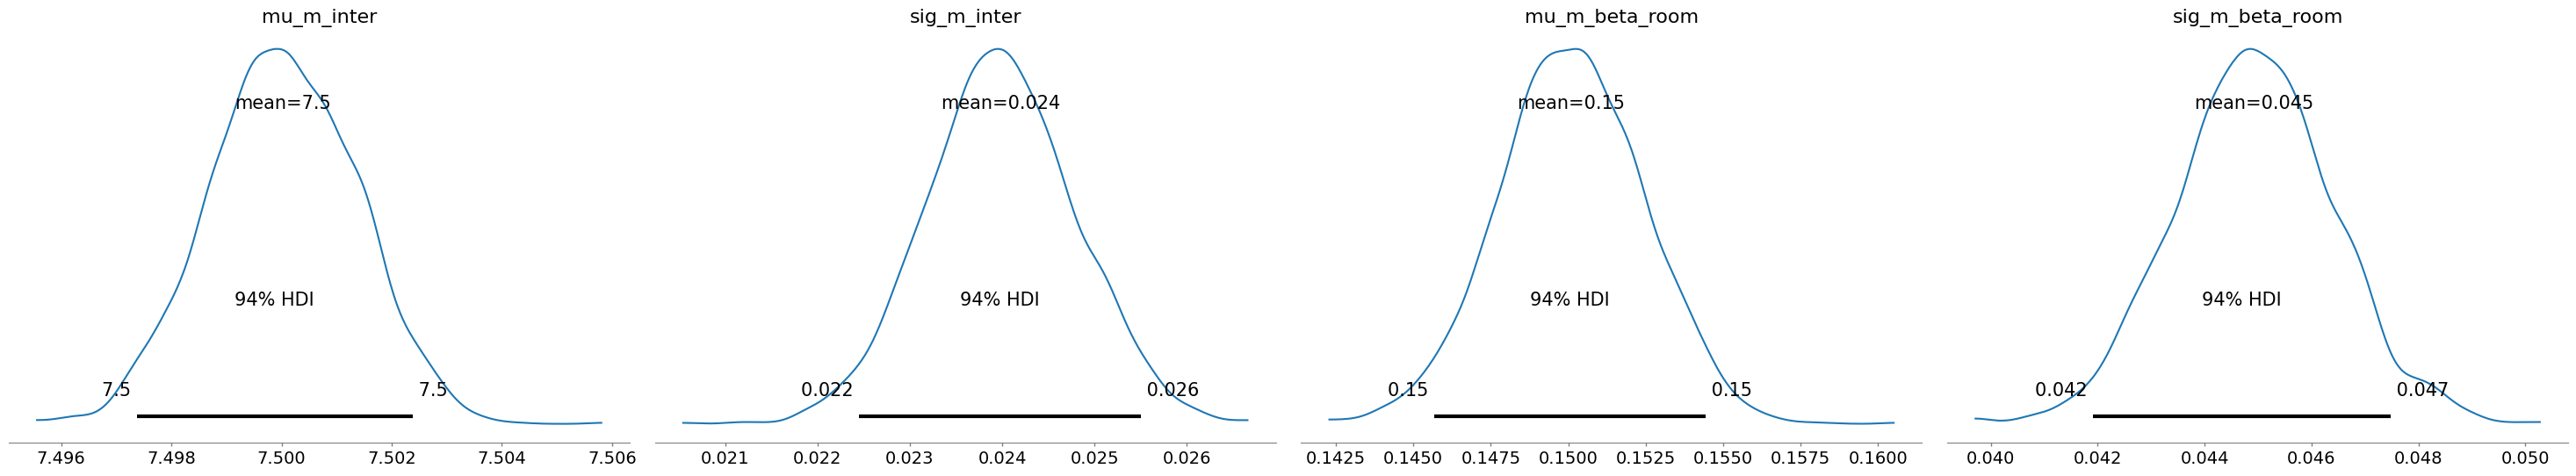

--- STRUCTURAL FEATURES (GLOBAL) ---


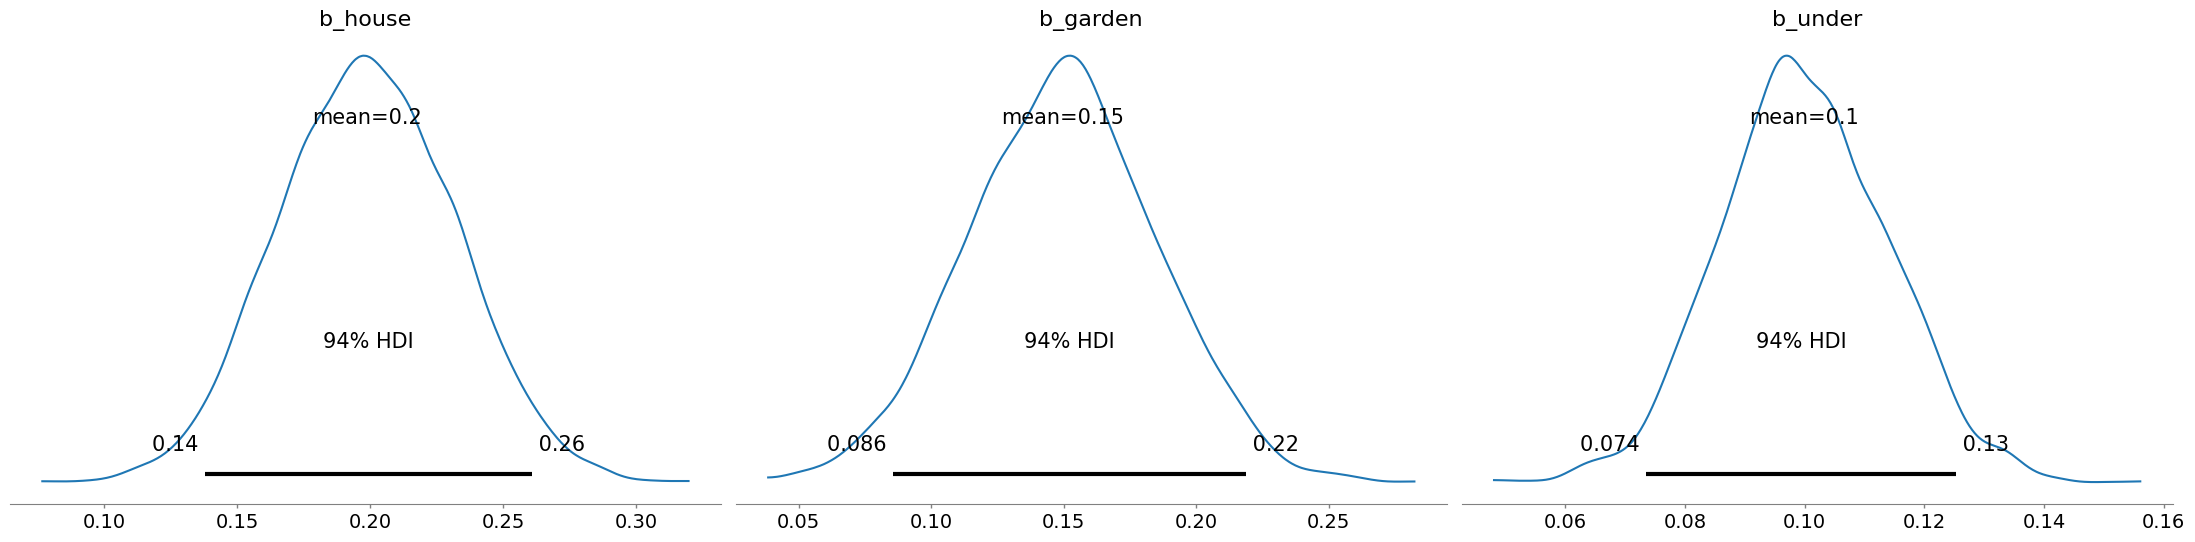

--- INDIVIDUAL PROPERTY RECOVERY (LOCAL - FIRST 3 PROPS) ---


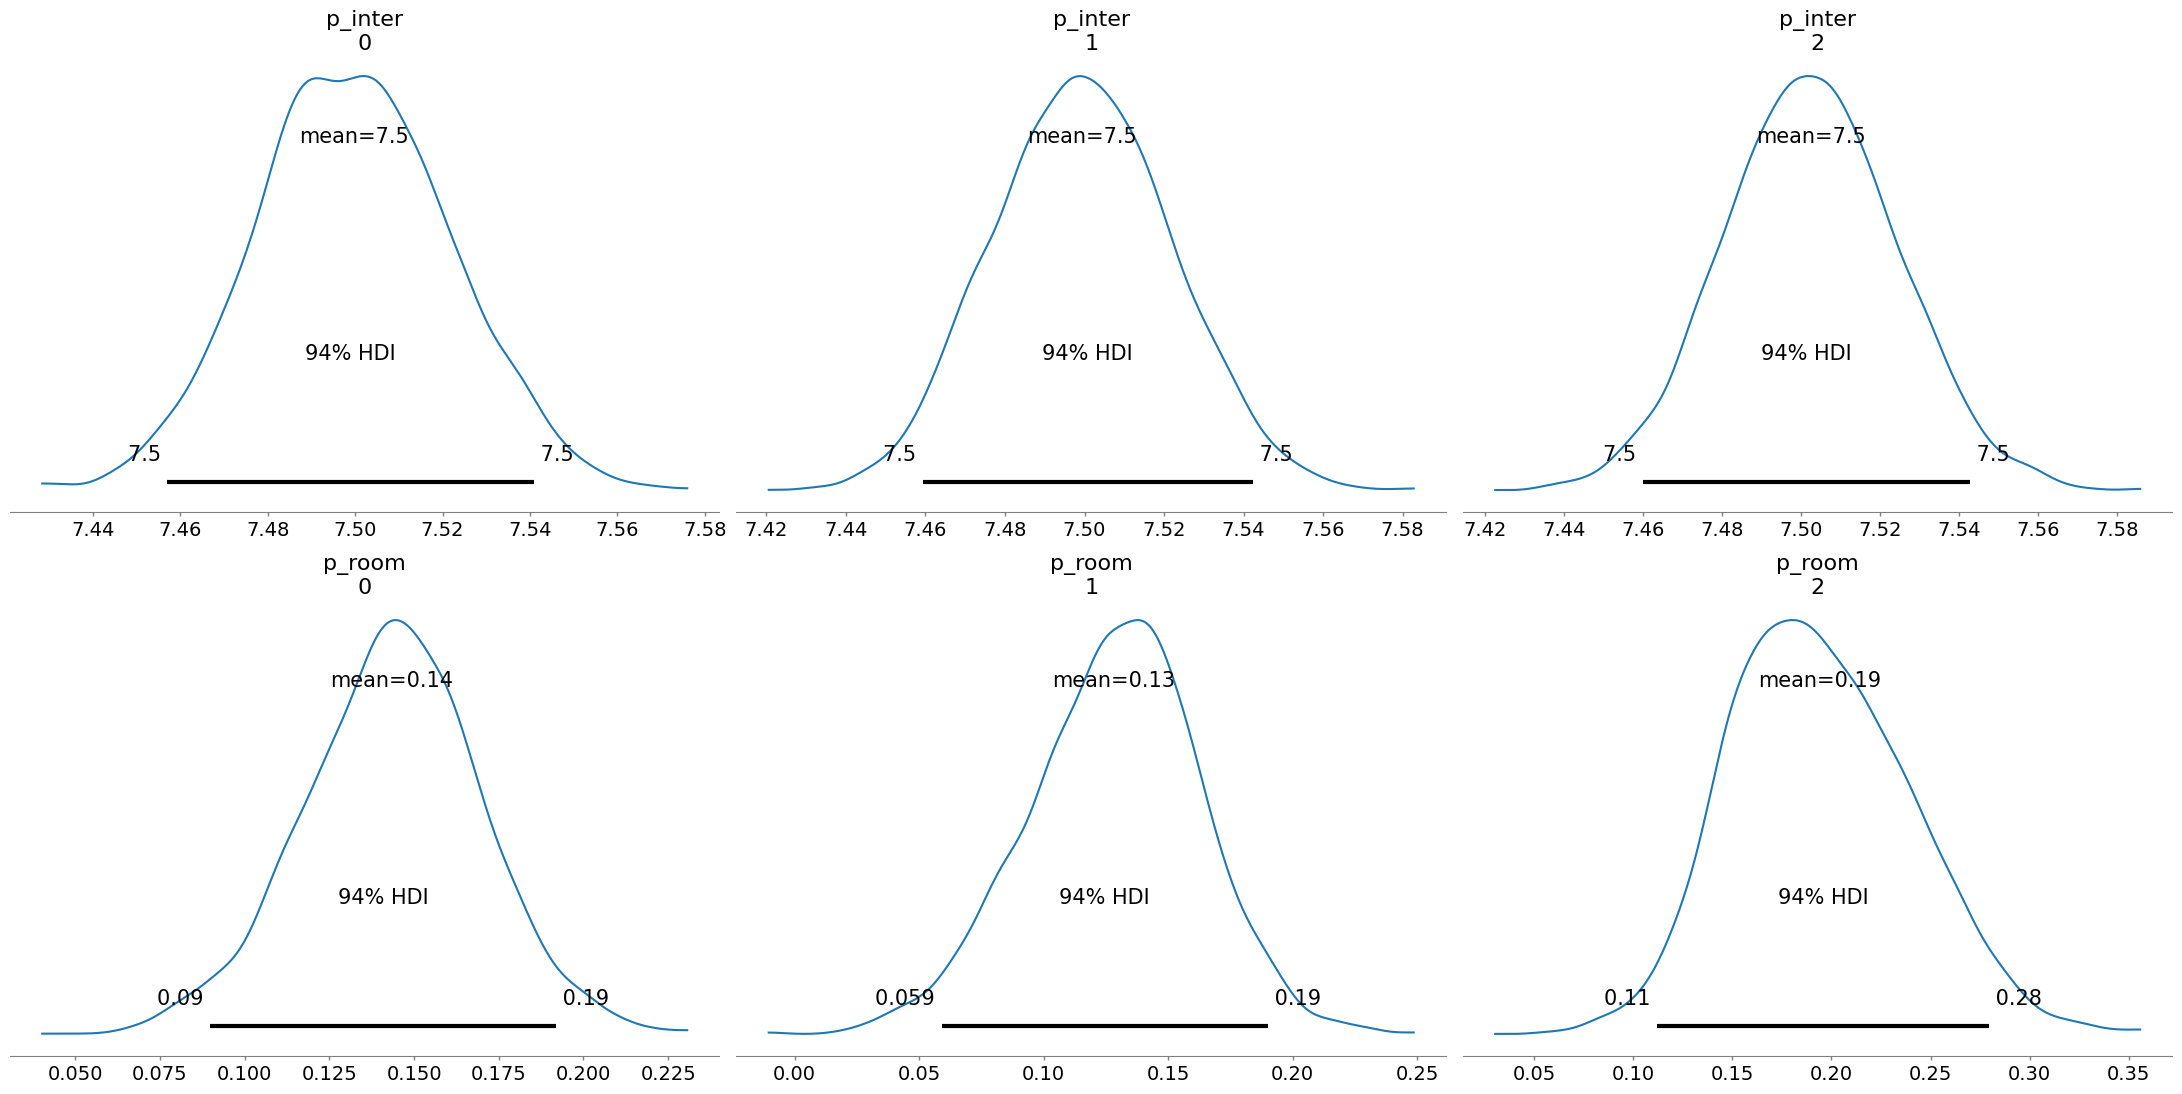

,intercept,beta_room
500,7.506178,0.163069
501,7.478196,0.139606
502,7.490916,0.251217


In [8]:
# ### OWNER
# # 1. Global Market Parameters (The "Mu" and "Sigma" of the market)
# # We look at the market-wide intercept and room effect means.
# print("--- MARKET HYPER-PARAMETERS (GLOBAL) ---")
# az.plot_posterior(res_owner, var_names=['mu_m_inter', 'sig_m_inter', 'mu_m_beta_room', 'sig_m_beta_room'])
# plt.tight_layout()
# plt.show()

# # 2. Structural Features (Fixed Effects)
# # These were estimated as one value for the whole batch (like 'House' recovery)
# print("--- STRUCTURAL FEATURES (GLOBAL) ---")
# az.plot_posterior(res_owner, var_names=['b_house', 'b_garden', 'b_under'])
# plt.tight_layout()
# plt.show()

# # 3. Individual Property Parameters (The "Wobbles")
# # We select the first 3 properties (index 0, 1, 2) to see local variation
# print("--- INDIVIDUAL PROPERTY RECOVERY (LOCAL - FIRST 3 PROPS) ---")
# # We use coords to sub-select from the 'shape=n_props' dimensions
# az.plot_posterior(res_owner, 
#                   var_names=['p_inter', 'p_room'], 
#                   coords={'p_inter_dim_0': [0, 1, 2], 'p_room_dim_0': [0, 1, 2]})
# plt.tight_layout()
# plt.show()

### AGENT
# 1. Global Market Parameters (The "Mu" and "Sigma" of the market)
# We look at the market-wide intercept and room effect means.
print("--- MARKET HYPER-PARAMETERS (GLOBAL) ---")
az.plot_posterior(res_agent, var_names=['mu_m_inter', 'sig_m_inter', 'mu_m_beta_room', 'sig_m_beta_room'])
plt.tight_layout()
plt.show()

# 2. Structural Features (Fixed Effects)
# These were estimated as one value for the whole batch (like 'House' recovery)
print("--- STRUCTURAL FEATURES (GLOBAL) ---")
az.plot_posterior(res_agent, var_names=['b_house', 'b_garden', 'b_under'])
plt.tight_layout()
plt.show()

# 3. Individual Property Parameters (The "Wobbles")
# We select the first 3 properties (index 0, 1, 2) to see local variation
print("--- INDIVIDUAL PROPERTY RECOVERY (LOCAL - FIRST 3 PROPS) ---")
# We use coords to sub-select from the 'shape=n_props' dimensions
az.plot_posterior(res_agent, 
                  var_names=['p_inter', 'p_room'], 
                  coords={'p_inter_dim_0': [0, 1, 2], 'p_room_dim_0': [0, 1, 2]})
plt.tight_layout()
plt.show()

test_batch[['intercept', 'beta_room']].head(3)

Generating Hierarchical PPC for Agent Model...


Sampling: [obs]


Output()

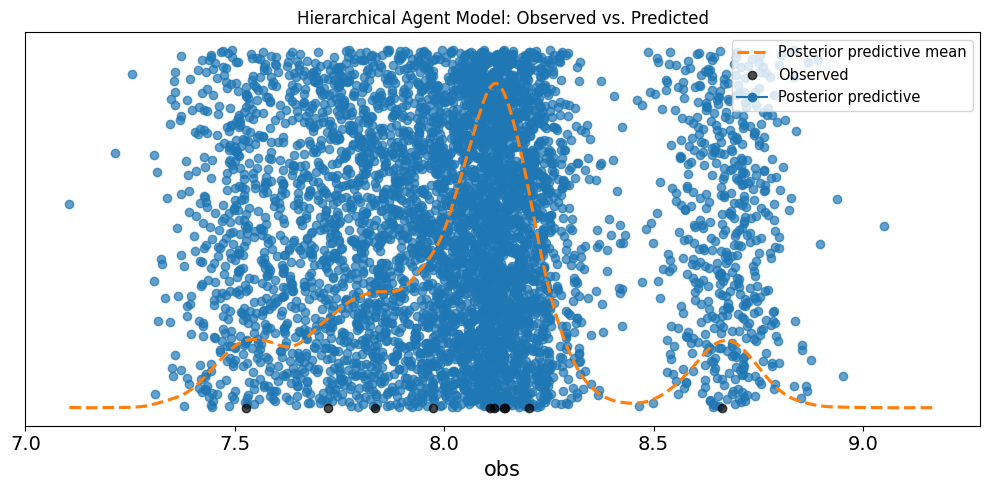

In [9]:
def perform_hierarchical_ppc(df_subset, market_truth, trace, is_agent_hyp=False):
    # 1. Reconstruct the Data Vectors
    n_props = len(df_subset)
    rooms = df_subset['n_rooms'].values
    dist = df_subset['dist_centre_km'].values
    is_under = df_subset['near_underground'].values
    is_house = (df_subset['property_type'] == 'House').astype(int)
    is_garden = (df_subset['outdoor_space'] == 'Garden').astype(int)
    is_terrace = (df_subset['outdoor_space'] == 'Terrace').astype(int)
    is_balcony = (df_subset['outdoor_space'] == 'Balcony').astype(int)
    y_obs = df_subset['log_rent'].values

    # 2. Re-define the Model Structure
    with pm.Model() as ppc_model:
        k = 0.05
        
        # Hyper-priors for Global Market Means
        mu_m_inter = pm.Normal("mu_m_inter", 
                               mu=market_truth["means"]["intercept"], 
                               sigma=k*market_truth["sigmas"]["intercept"])
        mu_m_beta_room = pm.Normal("mu_m_beta_room", 
                                   mu=market_truth["means"]["beta_room"], 
                                   sigma=k*market_truth["sigmas"]["beta_room"])
        mu_m_beta_dist = pm.Normal("mu_m_beta_dist", 
                                   mu=market_truth["means"]["beta_dist"], 
                                   sigma=k*market_truth["sigmas"]["beta_dist"])
        
        # Hyper-priors for Market Sigmas
        sig_m_inter = pm.TruncatedNormal("sig_m_inter", 
                                         mu=market_truth["sigmas"]["intercept"], 
                                         sigma=(k/np.sqrt(2))*market_truth["sigmas"]["intercept"],
                                         lower=(k/np.sqrt(2))*market_truth["sigmas"]["intercept"]/100,
                                         upper=market_truth["sigmas"]["intercept"]+\
            (market_truth["sigmas"]["intercept"]-(k/np.sqrt(2))*market_truth["sigmas"]["intercept"]/100))
        sig_m_beta_room = pm.TruncatedNormal("sig_m_beta_room", 
                                             mu=market_truth["sigmas"]["beta_room"], 
                                             sigma=(k/np.sqrt(2))*market_truth["sigmas"]["beta_room"],
                                             lower=(k/np.sqrt(2))*market_truth["sigmas"]["beta_room"]/100,
                                             upper=market_truth["sigmas"]["beta_room"]+\
            (market_truth["sigmas"]["beta_room"]-(k/np.sqrt(2))*market_truth["sigmas"]["beta_room"]/100))
        sig_m_beta_dist = pm.TruncatedNormal("sig_m_beta_dist", 
                                             mu=market_truth["sigmas"]["beta_dist"], 
                                             sigma=(k/np.sqrt(2))*market_truth["sigmas"]["beta_dist"],
                                             lower=(k/np.sqrt(2))*market_truth["sigmas"]["beta_dist"]/100,
                                             upper=market_truth["sigmas"]["beta_dist"]+\
            (market_truth["sigmas"]["beta_dist"]-(k/np.sqrt(2))*market_truth["sigmas"]["beta_dist"]/100))

        # Individual Property Parameters (The Hierarchical "Wobbles")
        p_inter = pm.Normal("p_inter", mu=mu_m_inter, sigma=sig_m_inter, shape=n_props)
        p_room = pm.Laplace("p_room", mu=mu_m_beta_room, b=sig_m_beta_room, shape=n_props)
        p_dist = pm.Normal("p_dist", mu=mu_m_beta_dist, sigma=sig_m_beta_dist, shape=n_props)

        # Linear Predictor
        mu = p_inter + (rooms * p_room) + (dist * p_dist)

        # Structural Features
        mu += pm.Normal("b_under", mu=market_truth["means"]["beta_under"], sigma=market_truth["sigmas"]["beta_under"]) * is_under
        mu += pm.Normal("b_house", mu=market_truth["means"]["beta_house"], sigma=market_truth["sigmas"]["beta_house"]) * is_house
        mu += pm.Normal("b_garden", mu=market_truth["means"]["beta_garden"], sigma=market_truth["sigmas"]["beta_garden"]) * is_garden
        mu += pm.Normal("b_terrace", mu=market_truth["means"]["beta_terrace"], sigma=market_truth["sigmas"]["beta_terrace"]) * is_terrace
        mu += pm.Normal("b_balcony", mu=market_truth["means"]["beta_balcony"], sigma=market_truth["sigmas"]["beta_balcony"]) * is_balcony
        
        if is_agent_hyp:
            # Reconstruct the Gamma Premium logic
            mu_m_prem = pm.Normal("mu_m_prem",
                                  mu=market_truth["means"]["premium"],
                                  sigma=k*market_truth["sigmas"]["premium"])
            sig_m_prem = pm.TruncatedNormal("sig_m_prem",
                                            mu=market_truth["sigmas"]["premium"],
                                            sigma=(k/np.sqrt(2))*market_truth["sigmas"]["premium"],
                                            lower=(k/np.sqrt(2))*market_truth["sigmas"]["premium"]/100,
                                            upper=market_truth["sigmas"]["premium"]+\
                (market_truth["sigmas"]["premium"]-(k/np.sqrt(2))*market_truth["sigmas"]["premium"]/100))
            
            alpha_p = (mu_m_prem / sig_m_prem)**2
            beta_p  = mu_m_prem / (sig_m_prem**2)
            
            p_premium = pm.Gamma("p_premium", alpha=alpha_p, beta=beta_p, shape=n_props)
            mu += p_premium

        # Likelihood
        pm.StudentT("obs", nu=5, mu=mu, sigma=0.05, observed=y_obs)

        # 3. Sample Posterior Predictive
        pm.sample_posterior_predictive(trace, extend_inferencedata=True)
    
    return trace

# --- EXECUTION ---
# Generate predictions for both models using the calculated res_owner and res_agent
print("Generating Hierarchical PPC for Agent Model...")
res_agent_ppc = perform_hierarchical_ppc(test_batch, market_truth, res_agent, is_agent_hyp=True)

# print("Generating Hierarchical PPC for Owner Model...")
# res_owner_ppc = perform_hierarchical_ppc(test_batch, market_truth, res_owner, is_agent_hyp=False)

# --- PLOTTING ---
# 1. Hierarchical PPC plot (Agent)
fig1, ax1 = plt.subplots(figsize=(10, 5))
az.plot_ppc(res_agent, kind="scatter", num_pp_samples=500, ax=ax1)
ax1.set_title("Hierarchical Agent Model: Observed vs. Predicted")
plt.tight_layout()
plt.show()

# 2. Hierarchical PPC plot (Owner) 
# fig2, ax2 = plt.subplots(figsize=(10, 5))
# az.plot_ppc(res_owner, kind="scatter", num_pp_samples=500, ax=ax2)
# ax2.set_title("Hierarchical Owner Model: Observed vs. Predicted")
# plt.tight_layout()
# plt.show()

In [10]:
res_agent.posterior.data_vars

Data variables:
    mu_m_inter       (chain, draw) float64 32kB 7.501 7.5 7.5 ... 7.501 7.499
    mu_m_beta_room   (chain, draw) float64 32kB 0.1501 0.1464 ... 0.1541 0.1522
    mu_m_beta_dist   (chain, draw) float64 32kB -0.04893 -0.04634 ... -0.05122
    p_inter          (chain, draw, p_inter_dim_0) float64 320kB 7.488 ... 7.502
    p_room           (chain, draw, p_room_dim_0) float64 320kB 0.2003 ... 0.1605
    p_dist           (chain, draw, p_dist_dim_0) float64 320kB -0.06969 ... -...
    b_under          (chain, draw) float64 32kB 0.1036 0.08923 ... 0.1091
    b_house          (chain, draw) float64 32kB 0.1931 0.204 ... 0.1995 0.192
    b_garden         (chain, draw) float64 32kB 0.1216 0.08864 ... 0.1835 0.1314
    b_terrace        (chain, draw) float64 32kB 0.0974 0.04435 ... 0.1304 0.1037
    b_balcony        (chain, draw) float64 32kB 0.03729 0.02999 ... 0.04687
    mu_m_prem        (chain, draw) float64 32kB 0.1517 0.1512 ... 0.1508 0.15
    sig_m_inter      (chain, draw) fl

In [ ]:
agent_vars = ["mu_m_beta_room", "sig_m_beta_room", "mu_m_premium", "sig_m_premium"]

In [4]:
test_batch = df[df['listing_type'] == 'Agent'].head(10)
